
# Anomaly Detection in Time

For the past few lessons, we have focused exclusively on predicting the future. But in the enterprise world of cybersecurity, algorithmic trading, and server reliability, predicting the future is often secondary to **monitoring the present**.

If an e-commerce website usually processes 500 transactions a minute, and suddenly processes 0 transactions for 3 consecutive minutes, a machine learning model needs to trigger a pager to wake up a DevOps engineer immediately.

However, finding anomalies in Time Series is vastly more complex than standard anomaly detection because **context is everything**. A sudden spike of 10,000 users at 2:00 AM on a Tuesday is a massive anomaly (likely a bot attack). That exact same spike at 9:00 AM on Black Friday is perfectly normal.

In this lesson, we will explore how to mathematically define, detect, and flag contextual anomalies.

Time series anomalies generally fall into three categories:

1. **Point Anomalies**: A single data point drastically out of bounds (e.g., a sensor glitches and reports a temperature of 5,000°C for one second).
2. **Contextual Anomalies**: A data point that is normal globally, but abnormal for that specific time (e.g., $100,000 in sales on a slow Tuesday).
3. **Collective Anomalies**: A sequence of data points that are normal individually, but abnormal together (e.g., a server's CPU utilization gets stuck at exactly 85% for 4 hours; 85% is safe, but lacking variance for 4 hours is highly suspicious).

Let's set up our Python environment to build enterprise monitoring systems.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from prophet import Prophet

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Temporal Anomaly Detection Environment Ready.")

✅ Temporal Anomaly Detection Environment Ready.


# 1. The Statistical Approach: Rolling MAD

In standard cross-sectional data, we find anomalies using a **Global Z-Score** ($z = \frac{x - \mu}{\sigma}$). If a data point is more than 3 standard deviations away from the global mean, it is flagged.

**Why this fails in Time Series:** If a business is growing rapidly (Trend), the Global Mean is mathematically useless. Today's perfectly normal data will be flagged as an anomaly simply because it is much higher than last year's data.

To fix this, we calculate **Rolling Statistics**. We compare today's value strictly against the recent local context. Furthermore, we abandon the Mean and Standard Deviation (which are easily corrupted by massive outliers) and use the **Median** and **Median Absolute Deviation (MAD)**.

$$\text{MAD} = \text{median}(|y_i - \tilde{y}|)$$


*(Where $\tilde{y}$ is the rolling median of the window).*

/tmp/ipykernel_39470/192202170.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = pd.DataFrame({'Traffic': traffic}, index=pd.date_range('2023-01-01', periods=300, freq='H'))


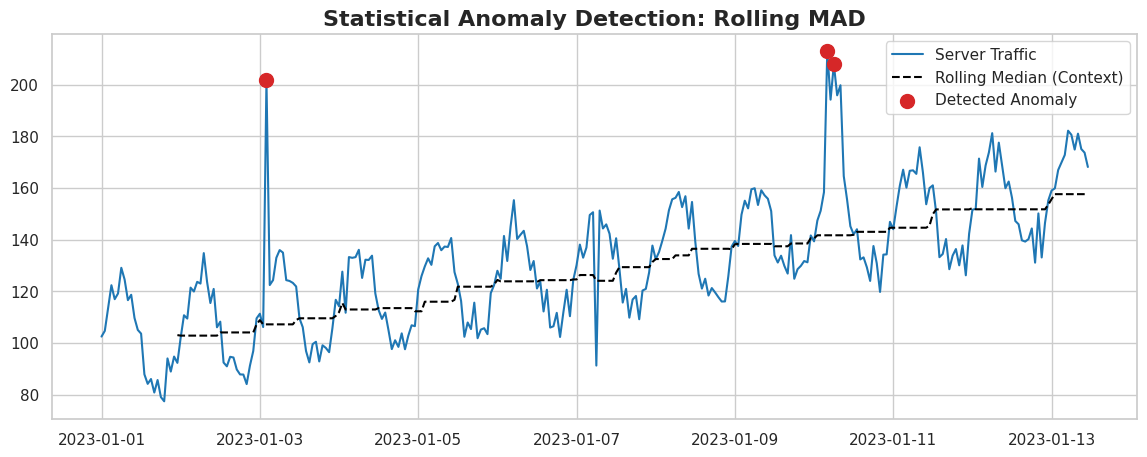

In [3]:
# 1. Simulate Server Traffic with Trend, Seasonality, and Anomalies
np.random.seed(42)
t = np.arange(300)
baseline = 100 + (t * 0.2) + np.sin(t * (2 * np.pi / 24)) * 20
noise = np.random.normal(0, 5, 300)

# Inject Point and Contextual Anomalies
anomalies = np.zeros(300)
anomalies[50] = 80   # Massive Point Spike
anomalies[150] = -60 # Massive Point Drop
anomalies[220:225] = 40 # Collective / Contextual Spike

traffic = baseline + noise + anomalies
df = pd.DataFrame({'Traffic': traffic}, index=pd.date_range('2023-01-01', periods=300, freq='H'))

# 2. Calculate Rolling Median and MAD (Window = 24 hours)
window = 24
df['Rolling_Median'] = df['Traffic'].rolling(window=window, center=False).median()

# A custom function to calculate MAD over a rolling window
def calc_mad(x):
    return np.median(np.abs(x - np.median(x)))

df['Rolling_MAD'] = df['Traffic'].rolling(window=window, center=False).apply(calc_mad)

# 3. Calculate the Robust Z-Score
# Note: 1.4826 is a mathematical constant used to scale MAD to approximate Standard Deviation
df['Robust_Z'] = (df['Traffic'] - df['Rolling_Median']) / (df['Rolling_MAD'] * 1.4826)

# 4. Flag Anomalies (Threshold: Absolute Z-Score > 3.5)
df['Is_Anomaly_Stat'] = np.where(np.abs(df['Robust_Z']) > 3.5, True, False)

# 5. Matplotlib Visualization
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Traffic'], color='#1f77b4', label='Server Traffic')
plt.plot(df.index, df['Rolling_Median'], color='black', linestyle='--', label='Rolling Median (Context)')

# Highlight the anomalies in Red
anom_points = df[df['Is_Anomaly_Stat']]
plt.scatter(anom_points.index, anom_points['Traffic'], color='#d62728', s=100, zorder=5, label='Detected Anomaly')

plt.title("Statistical Anomaly Detection: Rolling MAD", fontsize=16, fontweight='bold')
plt.legend()
plt.show()

# 2. The Machine Learning Approach: Isolation Forests

Rolling statistics are great for a single metric. But what if an anomaly is defined by the interaction of multiple variables? (e.g., CPU is at 90%, but Network IO is at 0%. Individually normal, but together they imply a frozen process).

We use **Isolation Forests**. This ML algorithm builds randomized Decision Trees. It attempts to isolate every single data point into its own leaf node.

* **The Math**: Normal data points are clustered together in the center of the data cloud; it takes many tree splits to isolate them. Outliers are located far away from the cloud; they are isolated in very few splits. The algorithm calculates an anomaly score based on the *average path length* required to isolate the point.

**The Time Series Trick**: Just like in Lesson 13, Isolation Forests are time-blind. You must Tabularize the data. You must feed the Isolation Forest the Calendar Features (Hour, Day) and Lags, so it understands that "90% CPU" + "2:00 AM" = Anomaly.

In [4]:
# 1. Tabularize the Data for the Isolation Forest
df_ml = df[['Traffic']].copy()
df_ml['Hour'] = df_ml.index.hour
df_ml['Lag_1'] = df_ml['Traffic'].shift(1)
df_ml['Lag_24'] = df_ml['Traffic'].shift(24) # What happened exactly yesterday?
df_ml = df_ml.dropna()

# 2. Train the Isolation Forest
# contamination=0.02 tells the model to assume exactly 2% of the data is fraudulent/anomalous
iso_forest = IsolationForest(contamination=0.02, random_state=42)
df_ml['Anomaly_Score'] = iso_forest.fit_predict(df_ml[['Traffic', 'Hour', 'Lag_1', 'Lag_24']])

# 3. Flag Anomalies (Isolation Forest returns -1 for anomalies, 1 for normal data)
df_ml['Is_Anomaly_ML'] = df_ml['Anomaly_Score'] == -1

print("🚨 Isolation Forest Processing Complete.")
print(f"Total Anomalies Detected: {df_ml['Is_Anomaly_ML'].sum()}")


🚨 Isolation Forest Processing Complete.
Total Anomalies Detected: 6


# 3. The Forecasting Approach: Prophet Bounds

The absolute gold standard for enterprise anomaly detection is treating it as a forecasting problem.

If you build a highly accurate forecasting model (like SARIMAX or a Transformer) and generate **Prediction Intervals** (Lesson 19), you have mathematically defined the exact boundaries of normal behavior.
If an actual data point lands outside the 99% Prediction Interval, it is, by definition, an anomaly.

**Facebook Prophet** is widely used for this. It is an open-source forecasting library built specifically to handle messy, daily enterprise data with strong seasonality and holidays. It natively generates robust uncertainty intervals.

15:30:35 - cmdstanpy - INFO - Chain [1] start processing
15:30:35 - cmdstanpy - INFO - Chain [1] done processing


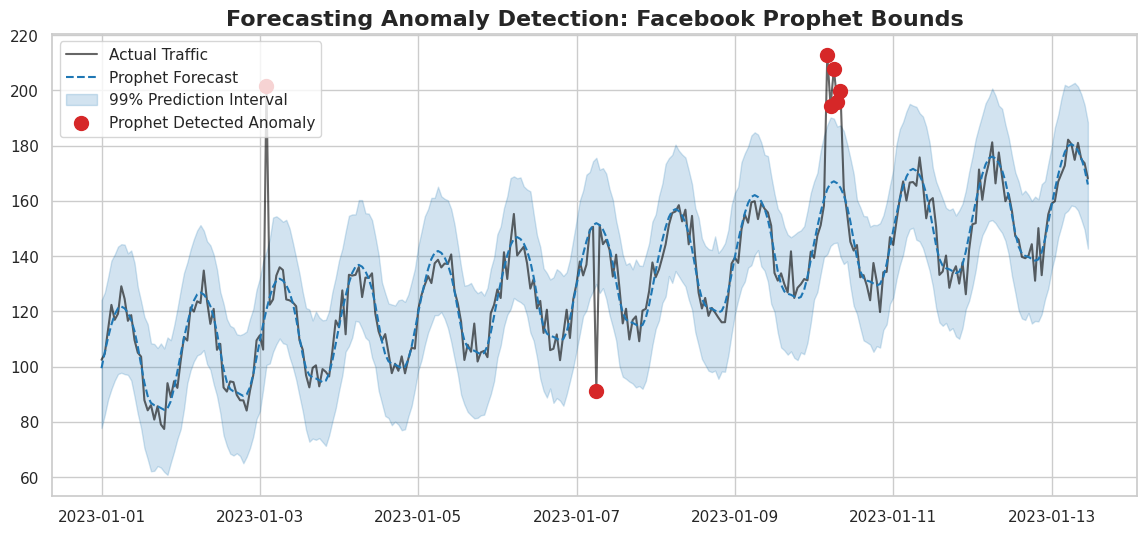

In [5]:
# 1. Format the data strictly for Prophet (Requires columns 'ds' and 'y')
df_prophet = df.reset_index()[['index', 'Traffic']].rename(columns={'index': 'ds', 'Traffic': 'y'})

# 2. Train the Prophet Model
# interval_width=0.99 means we want the 99% Prediction Interval
model_prophet = Prophet(interval_width=0.99, yearly_seasonality=False, daily_seasonality=True)
model_prophet.fit(df_prophet)

# 3. Predict on the historical data to generate the bounds
forecast = model_prophet.predict(df_prophet)

# 4. Merge the true actuals with the Prophet bounds
results = pd.merge(df_prophet, forecast[['ds', 'yhat_lower', 'yhat_upper', 'yhat']], on='ds')

# 5. Flag Anomalies (Actual > Upper Bound OR Actual < Lower Bound)
results['Is_Anomaly_Prophet'] = (results['y'] > results['yhat_upper']) | (results['y'] < results['yhat_lower'])

# 6. Matplotlib Visualization
plt.figure(figsize=(14, 6))

plt.plot(results['ds'], results['y'], color='black', label='Actual Traffic', alpha=0.6)
plt.plot(results['ds'], results['yhat'], color='#1f77b4', linestyle='--', label='Prophet Forecast')

# Plot the 99% Prediction Interval
plt.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'], color='#1f77b4', alpha=0.2, label='99% Prediction Interval')

# Highlight Anomalies
anom_prophet = results[results['Is_Anomaly_Prophet']]
plt.scatter(anom_prophet['ds'], anom_prophet['y'], color='#d62728', s=100, zorder=5, label='Prophet Detected Anomaly')

plt.title("Forecasting Anomaly Detection: Facebook Prophet Bounds", fontsize=16, fontweight='bold')
plt.legend(loc='upper left')
plt.show()

*(Insight: Look closely at Prophet's blue prediction interval cone. It organically expands and contracts based on the time of day. Because it understands the rhythm of the data, it ignores the normal daily peaks, and surgically targets only the mathematical violations!)*

## Real-World Use Case or Analogy:

Think of Time Series Anomaly Detection like **A Bank's Fraud Department monitoring a Credit Card**:

* **Standard Global Detection (Fails)**: The bank flags any transaction over $\$1,000$. This fails because a billionaire might spend $\$1,000$ every day for lunch. For them, it is normal.
* **Rolling MAD (Local Context)**: The bank calculates your average spend over the last 14 days. If your rolling average is $\$20$, and suddenly you buy a $\$900$ TV, it flags the transaction. It adjusts to *your* baseline.
* **Isolation Forest (Multivariate)**: The bank looks at multiple features. A $\$20$ charge is normal. A charge in Russia is normal (if you live there). But a $\$20$ charge in Russia, exactly 5 minutes after a $\$5$ charge in New York, is physically impossible. The interaction of the features isolates the anomaly.
* **Forecasting Bounds (Prophet)**: The bank builds a predictive model of your life. It knows you pay a $\$2,500$ mortgage on the 1st of every month. When a $\$2,500$ charge hits on December 1st, it doesn't blink, because it *forecasted* it. It only flags transactions that violate the mathematical rhythm of your specific life.